### Workbook to process medical CT images. 

#### Packages to run notebook

In [1]:
import os
import numpy as np
import SimpleITK as sitk

import matplotlib.pyplot as plt
from ipywidgets import interact, IntSlider, FloatSlider, Dropdown
from typing import List, Tuple, Dict, Union 

import pydicom

from matplotlib.animation import FuncAnimation
from mpl_toolkits.axes_grid1.anchored_artists import AnchoredSizeBar
from PIL import Image
import tempfile
import os

import pandas as pd
from datetime import datetime, timedelta
import csv

from typing import List, Optional

import pandas as pd
from dateutil.relativedelta import relativedelta
import cv2
from matplotlib.patches import Circle
import glob

import re

from matplotlib.widgets import CheckButtons
import mplcursors


## to run interactive features in this jupyter notebook
#%matplotlib widget


## Processing functions

### Automated centering code

In [2]:

def find_center_coeff(image_array):
    # Normalize the pixel array to the range 0-255 (optional, depending on the image characteristics)
    image_array = (np.maximum(image_array, 0) / image_array.max()) * 255.0
    image_array = np.uint8(image_array)

    # Ensure the image array is not empty and is in the correct format
    if image_array is None or image_array.size == 0:
        print("Error: The image array is empty or not defined correctly")
    else:
        # Convert to 3-channel BGR if necessary (assuming the image array is grayscale)
        if len(image_array.shape) == 2:
            gray = image_array
        else:
            gray = cv2.cvtColor(image_array, cv2.COLOR_BGR2GRAY)

        blurred = cv2.GaussianBlur(gray, (9, 9), 2)

        # Adjust parameters for better circle detection
        #circles = cv2.HoughCircles(blurred, cv2.HOUGH_GRADIENT_ALT, dp=1, minDist=120, param1=0.9, param2=0.9, minRadius=100, maxRadius=300)
        circles = cv2.HoughCircles(blurred, cv2.HOUGH_GRADIENT, dp=1.5, minDist=120, param1=100, param2=100, minRadius=190, maxRadius=300)

        # Ensure at least one circle was found
        if circles is not None:
            circles = np.round(circles[0, :]).astype("int")

            # Get the coordinates of the detected circle
            for (x, y, r) in circles:
                circle_center_x = x
                circle_center_y = y
                print(f"Offset to center the circle: (x: {circle_center_x}, y: {circle_center_y})")

                if r < 100 or r> 300:
                    print('Incorrect circle radii found')
        else:
            print("No circles were found")
    return circle_center_x, circle_center_y  


### Loading in files 

In [3]:
#finding directory 
def get_folder_names(exp: str, file_path):
    #Retrieve the names of the folders for the given experiment.
    def list_all_folders(exp_path: str) -> List[str]:
    #List all folders within the experiment path.
        return [f.name for f in os.scandir(exp_path) if f.is_dir()]

    exp_path = os.path.join(file_path, exp)
    folder_names = list_all_folders(exp_path)
    return folder_names, exp_path


def read_dicom_file(file_path: str) -> np.ndarray:
    #Read a DICOM file from the given path
    dicom_file = pydicom.dcmread(file_path, force = "True")
    dicom_file.file_meta.TransferSyntaxUID = pydicom.uid.ImplicitVRLittleEndian  
        
    # Extract the date and time from the relevant DICOM tags
    study_date = dicom_file.get('StudyDate', 'Unknown')
    study_time = dicom_file.get('StudyTime', 'Unknown')
    series_date = dicom_file.get('SeriesDate', 'Unknown')
    series_time = dicom_file.get('SeriesTime', 'Unknown')
    acquisition_date = dicom_file.get('AcquisitionDate', 'Unknown')
    acquisition_time = dicom_file.get('AcquisitionTime', 'Unknown')



    # Combine date and time into a single string
    datetime_str = acquisition_date + acquisition_time
    datetime_format = "%Y%m%d%H%M%S"
    acquisition_datetime = datetime.strptime(datetime_str, datetime_format)
        
    return dicom_file.pixel_array.astype(float), acquisition_datetime



def center_rock_sample(image: np.ndarray, cy: int, cx: int, cr: int) -> np.ndarray:
    #centering correction 
    nr, nc = image.shape
    yy, xx = np.meshgrid(range(1, nr + 1), range(1, nc + 1), indexing='ij')
    c_mask = ((yy - cy) ** 2 + (xx - cx) ** 2 <= cr ** 2)
    dummy = np.ones_like(image)
    dummy *= c_mask
    dummy[dummy == 0] = np.nan
    centered_image = image * dummy
    return centered_image

def find_center_list(path_to_files: List[str], folder_name: List[str], start_slice, num_slices, cr): 
    os.chdir(os.path.join(path_to_files, folder_name))
    image_names = os.listdir()

    im_num1 = start_slice + 10
    im_num2 = start_slice + num_slices - 10

    #find centering parameters
    slice1, slice1_time = read_dicom_file(image_names[im_num1])
    slice2, slice2_time = read_dicom_file(image_names[im_num2])

    cy1, cx1 = find_center_coeff(slice1)
    cy2, cx2 = find_center_coeff(slice2)
    #switch of x and y 8th Aug
    
    '''
    fig, axes = plt.subplots(1, 2, figsize=(8, 8))
    image1_wet = center_rock_sample(slice1, cy=cx1, cx=cy1, cr=cr+20)
    axes[0].imshow(image1_wet)
    axes[0].add_patch(Circle((cy1, cx1), cr, fill=False, linestyle='--', color='r'))
    axes[0].add_patch(Circle((cy1, cx1), cr+20, fill=False, linestyle='--', color='k'))
    axes[0].set_title('Image 1')
    axes[0].set_ylabel('cx')
    axes[0].set_xlabel('cy')


    image2_wet = center_rock_sample(slice2, cy=cx2, cx=cy2, cr=cr+20)
    axes[1].imshow(image2_wet)
    axes[1].add_patch(Circle((cy2, cx2), cr, fill=False, linestyle='--', color='r'))
    axes[1].add_patch(Circle((cy2, cx2), cr+20, fill=False, linestyle='--', color='k'))
    axes[1].set_title('Image 2')
    plt.tight_layout()
    plt.show()
    '''

    ### calculating centering points for the image correction 
    slope_cx = (cx1 - cx2) / (num_slices - 1)
    Intpt_cx = cx1 - slope_cx
    slope_cy = (cy1 -cy2) / (num_slices - 1)
    Intpt_cy = cy1 - slope_cy

    cx = [round(slope_cx * i + Intpt_cx) for i in range(1, num_slices + 1)]
    cy = [round(slope_cy * i + Intpt_cy) for i in range(1, num_slices + 1)]
    

    return cx, cy  


#load in images and correct for any slope between intial and final scan 
def load_process_scan(path_to_files: List[str], folder_name: List[str], start_slice: int, num_slices:int, cr: int, cx_list: Optional[List[int]] = None, cy_list: Optional[List[int]] = None) -> Tuple[np.ndarray, List[float]]:
    """
    Process flow scans by reading DICOM files, averaging, masking, reorienting, and calculating CT numbers.

    Args:
        file_paths (List[str]): List of file paths to the DICOM files.
        cx_list (List[int]): List of center x-coordinates.
        cy_list (List[int]): List of center y-coordinates.
        cr (int): Radius for masking.

    Returns:
        Tuple[np.ndarray, List[float]]: Tuple containing the processed 3D image array and slice-averaged CT numbers.
    """
    #change directory to one of interest 
    os.chdir(os.path.join(path_to_files, folder_name))
    image_names = os.listdir()

    def extract_sort_key(filename):
        match = re.search(r'_(\d+)_', filename)
        if match:
            return int(match.group(1))
        return 0
    
    sorted_image_names = sorted(image_names, key=extract_sort_key)
    images_to_process = sorted_image_names[start_slice:start_slice + num_slices]    

    if cx_list is None or cy_list is None:
        cx_list, cy_list = find_center_list(path_to_files, folder_name, start_slice, num_slices, cr)



    processed_images = []
    ct_numbers = []
    for kk, file_path in enumerate(reversed(images_to_process)):
        cx, cy = cx_list[kk], cy_list[kk]
        image, time = read_dicom_file(file_path)
        centered_image = center_rock_sample(image, cx, cy, cr)
        processed_images.append(centered_image)
        ct_number = np.nanmean(centered_image)
        ct_numbers.append(ct_number)

    print(folder_name)
    return np.array(processed_images), ct_numbers, time

def averaging_scans(path_to_files: List[str], folder_name: List[str], no_scans: int, start_slice:int, num_slices: int, cr: int, cx_list: Optional[List[int]] = None, cy_list: Optional[List[int]] = None): 
    #average multiple scans
    processed_images_all = [] 
    for i in range(start_slice, (no_scans*num_slices) + start_slice, num_slices):
        if cx_list is None or cy_list is None:
            processed_images, ct_numbers, times = load_process_scan(path_to_files, folder_name, i, num_slices, cr)
        else: 
            processed_images, ct_numbers, times = load_process_scan(path_to_files, folder_name, i, num_slices, cr, cx_list=cx_list, cy_list=cy_list)
        processed_images_all.append(processed_images)
        plt.plot(ct_numbers[15:-15])
        print('Mean CT number', np.mean(ct_numbers[15:-15]))
    plt.ylabel('CT number')
    plt.xlabel('Slice number')
    
    average_scans = np.mean(processed_images_all, axis=0)
    return average_scans

### Processing functions

In [4]:
def apply_coarsening(image: np.ndarray, coarse: int) -> np.ndarray:
    # Reshape the image to apply coarsening
    shape = (image.shape[0] // coarse, coarse, image.shape[1] // coarse, coarse)
    coarsened_image = image.reshape(shape).mean(-1).mean(1)
    return coarsened_image

def calculate_porosity(image_dry: np.ndarray, image_wet: np.ndarray, CT_water: float, CT_air: float, coarse: int, rockin: int, rockout: int) -> Tuple[np.ndarray, np.ndarray, List[float]]:
    """
    Perform porosity calculations by calculating 2D porosity, applying coarsening, computing 3D porosity, and calculating slice-averaged porosity.

    Args:
        images (np.ndarray): Array containing the images.
        CT_water (float): CT number for water.
        CT_air (float): CT number for air.
        coarse (int): Coarsening factor.

    Returns:
        Tuple[np.ndarray, np.ndarray, List[float]]: Tuple containing 2D porosity array, 3D porosity array, and slice-averaged porosity.
    """

    images_porosity              = (image_wet - image_dry) / (CT_water - CT_air) 
    voxel_porosity_coarsened     = [apply_coarsening(image, coarse) for image in images_porosity]
    slice_averaged_porosity      = [np.nanmean(image) for image in voxel_porosity_coarsened] #ignoring voxels  < 0
    core_averaged_porosity       = np.nanmean(slice_averaged_porosity[rockin:rockout])
    voxel_porosity_coarsened     = np.array(voxel_porosity_coarsened)
    return voxel_porosity_coarsened[rockin:rockout, ...], core_averaged_porosity, slice_averaged_porosity[rockin:rockout] 


def calculate_saturation(image_flow: np.ndarray, image_wet: np.ndarray, porosity_voxels: np.ndarray, porosity: np.ndarray, CT_water: float, CT_air: float, coarse: int, rockin: int, rockout: int) -> Tuple[np.ndarray, np.ndarray, List[float]]:
    """
    Perform porosity calculations by calculating 2D porosity, applying coarsening, computing 3D porosity, and calculating slice-averaged porosity.

    Args:
        images (np.ndarray): Array containing the images.
        CT_water (float): CT number for water.
        CT_air (float): CT number for air.
        coarse (int): Coarsening factor.

    Returns:
        Tuple[np.ndarray, np.ndarray, List[float]]: Tuple containing 2D porosity array, 3D porosity array, and slice-averaged porosity.
    """

    images_sat              = (image_flow-image_wet) / (CT_air-CT_water) 
    voxel_sat_coarsened     = [apply_coarsening(image, coarse) for image in images_sat]
    voxel_sat_coarsened     = np.array(voxel_sat_coarsened)
    voxel_sat_coarsened     = voxel_sat_coarsened[rockin:rockout, ...] 
    voxel_sat_coarsened[voxel_sat_coarsened < 0] = 0  #values < 0 are assigned as 0 
    slice_averaged_sat      = [np.nanmean(image) for image in voxel_sat_coarsened]
    slice_averaged_sat      = [a / b for a, b in zip(slice_averaged_sat, porosity)]
    voxel_sat_coarsened     = voxel_sat_coarsened/porosity_voxels
    core_averaged_sat       = np.nanmean(slice_averaged_sat)
    print('The average saturation for the core is', core_averaged_sat)
    return voxel_sat_coarsened, core_averaged_sat, slice_averaged_sat


def calculate_saturation_CO2(image_flow: np.ndarray, image_wet: np.ndarray, image_CO2sat: np.ndarray, coarse: int, rockin: int, rockout: int) -> Tuple[np.ndarray, np.ndarray, List[float]]:
    """
    Perform porosity calculations by calculating 2D porosity, applying coarsening, computing 3D porosity, and calculating slice-averaged porosity.

    Args:
        images (np.ndarray): Array containing the images.
        CT_water (float): CT number for water.
        CT_air (float): CT number for air.
        coarse (int): Coarsening factor.

    Returns:
        Tuple[np.ndarray, np.ndarray, List[float]]: Tuple containing 2D porosity array, 3D porosity array, and slice-averaged porosity.
    """

    single_phase_subtract   =  image_CO2sat -image_wet
    single_phase_subtract[single_phase_subtract==0]   = np.inf
    images_sat              = (image_flow-image_wet) / single_phase_subtract
    voxel_sat_coarsened     = [apply_coarsening(image, coarse) for image in images_sat]
    voxel_sat_coarsened     = np.array(voxel_sat_coarsened)
    voxel_sat_coarsened     = voxel_sat_coarsened[rockin:rockout, ...] 
    voxel_sat_coarsened[voxel_sat_coarsened < 0] = 0       #values < 0 are assigned as 0 
    slice_averaged_sat      = [np.nanmean(image) for image in voxel_sat_coarsened]
    core_averaged_sat       = np.nanmean(slice_averaged_sat)
    print('The average saturation for the core is', core_averaged_sat)
    return voxel_sat_coarsened, core_averaged_sat, slice_averaged_sat


def plot_slice_averaged_profiles(slice_averaged: List[float], label: str, title: str, marker: Optional[str] = None) -> None:
    size_slice = 0.0625 
    """
    Plot slice-averaged profiles for porosity and CT numbers.

    Args:
        slice_averaged_porosity (List[float]): Slice-averaged porosity values.
        ct_numbers (List[float]): CT numbers for the slices.
        label (str): Label for the plot.
        title (str): Title for the plot.
        marker (Optional[str]): Marker shape for the plot (default is None).
    """
    if marker:
        plt.plot(np.linspace(0, len(slice_averaged)*size_slice, num=len(slice_averaged)), slice_averaged, label=label, marker=marker, markersize=5)
    else:
        plt.plot(np.linspace(0, len(slice_averaged)*size_slice, num=len(slice_averaged)), slice_averaged, label=label)
        
    plt.legend(fontsize='12')
    plt.title(title, loc='left', fontsize='16')
    plt.xlabel("Distance from inlet (cm)", fontsize='14')
    plt.ylabel("Gas saturation", fontsize='14')


### Plotting tools

In [5]:
def trapping_efficiency(slice_averaged_sat_dict, key_drain, key_imb, C = 2):
    key1 = 'slice_averaged_sat_' + str(key_drain)
    key2 = 'slice_averaged_sat_' + str(key_imb)

    value1 = slice_averaged_sat_dict[key1]
    value2 = slice_averaged_sat_dict[key2]
    
    trapping_efficiency = 100* (np.mean(value2)/ np.mean(value1))

    # Create a DataFrame
    df = pd.DataFrame({
        "Initial Saturation": value1,
        "Residual Saturation": value2,
        "Trapping Efficiency (%)": trapping_efficiency
    })

    # Define the folder and filename
    folder_path = "E:/Otway_cores/trapping_data"
    file_path = os.path.join(folder_path, "trapping_data.csv")

    # Ensure the folder exists
    os.makedirs(folder_path, exist_ok=True)

    # Save to CSV
    df.to_csv(file_path, index=False)

    print(f"CSV file saved to: {file_path}")

    # Generate Land trapping curve
    Si = np.linspace(0, 0.6, 100)
    Sr = Si / (1 + C*Si) 

    plt.figure()
    plt.plot(value1, value2, 'x', label='Data')
    plt.plot([0, 0.5], [0, 0.5], 'r-', label='1:1 line')
    plt.plot(Si, Sr, 'b-', label='Land trapping curve (C={})'.format(C))

    plt.xlabel("Initial saturation")
    plt.ylabel("Residual saturation")
    plt.title("Trapping efficiency")
    plt.legend()
    plt.show()

def voxel_sat_distribution(voxel_sat_dict, key):
    key1 = 'voxel_sat_' + str(key)
    value1 = voxel_sat_dict[key1]
    value1 = value1.flatten()

    # Get histogram values without plotting
    counts, bin_edges = np.histogram(value1, bins=50, range=(0, 1))
    
    # Sum the counts for the first 10 bins and the next 40 bins
    first_10_bins_sum = np.sum(counts[:10])
    next_40_bins_sum = np.sum(counts[10:])
    
    # Calculate the ratio
    if next_40_bins_sum != 0:  # Avoid division by zero
        ratio = first_10_bins_sum / next_40_bins_sum
    else:
        ratio = float('inf')  # Assign infinity if next_40_bins_sum is zero

    print(f"Ratio of values in the first 10 bins to the next 40 bins: {ratio}")
    # Plot histogram
    plt.hist(value1, bins=50, edgecolor='black', range=(0, 1))
    plt.title(f'Voxel Saturation Distribution for {key}')
    plt.xlabel('Saturation Value')
    plt.ylabel('Frequency')
    plt.xlim(0,1) 

def trapping_efficiency_voxel(voxel_sat_dict, key_drain, key_imb, C = 2):
    key1 = 'voxel_sat_' + str(key_drain)
    key2 = 'voxel_sat_' + str(key_imb)

    value1 = voxel_sat_dict[key1]
    value2 = voxel_sat_dict[key2]
    value1 = value1.flatten()
    value2 = value2.flatten()

    print(value1, value2)

    print('Average trapping efficiency', np.mean(value1)/ np.mean(value2))

    # Generate Land trapping curve
    Si = np.linspace(0, 0.6, 100)
    Sr = Si / (1 + C*Si) 

    plt.figure()
    plt.plot(value1, value2, 'x', label='Data')
    plt.plot([0, 0.5], [0, 0.5], 'r-', label='1:1 line')
    plt.plot(Si, Sr, 'b-', label='Land trapping curve (C={})'.format(C))

    plt.xlabel("Initial saturation")
    plt.ylabel("Residual saturation")
    plt.title("Trapping efficiency")
    plt.xlim(0,1)
    plt.ylim(0,1)
    plt.legend()
    plt.show()

def find_mean_sat_dict(slice_averaged_sat_dict, key): 
    dict_key = 'slice_averaged_sat_' + str(key)
    value    = slice_averaged_sat_dict[dict_key]
    mean_sat = np.mean(value)
    return mean_sat

def find_mean_pressure_dict(pressure_dict, key): 
    dict_key      = 'pressure_' + str(key)
    value         = pressure_dict[dict_key]
    mean_pressure = np.mean(value)
    return mean_pressure

def plot_saturation_vs_pressure(slice_averaged_sat_dict, pressure_dict):
    plt.figure()
    mean_pressure_all = []
    mean_sat_all = []
    for key, value in pressure_dict.items():
        key_label = key.split('_')[1]
        mean_pressure = np.mean(value)
        mean_sat      = find_mean_sat_dict(slice_averaged_sat_dict, key_label)
        plt.plot(mean_sat, mean_pressure, marker='o', markersize=10,  label = key)
        mean_pressure_all.append(mean_pressure)
        mean_sat_all.append(mean_sat)
    
    plt.ylabel('Pressure (kPa)')
    plt.xlabel('Gas saturation')
    plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left', borderaxespad=0.)
    return mean_pressure_all, mean_sat_all

def plotting_saturation(slice_averaged_sat_dict): 
    # Plot each entry in the dictionary
    plt.figure()
    for key, value in slice_averaged_sat_dict.items():
        plt.plot(value, label = key)

    plt.xlabel("Distance from inlet")
    plt.ylabel("Saturation")
    plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left', borderaxespad=0.)
    plt.show()

def plotting_saturation_interactive(slice_averaged_sat_dict):
    # Create figure and axis
    fig, ax = plt.subplots()
    lines = []

    # Plot each entry in the dictionary
    for key, value in slice_averaged_sat_dict.items():
        line, = ax.plot(value, label=key)
        lines.append(line)
    
    # Create legend with interactive visibility
    #leg = ax.legend(bbox_to_anchor=(1.05, 1), loc='upper left', borderaxespad=0.)
    leg = ax.legend(fancybox=True, shadow=True, loc='center right', bbox_to_anchor=(1.5, 0.5))

    map_legend_to_ax = {} 
    pickradius = 5  # Points (Pt). How close the click needs to be to trigger an event.

    for legend_line, ax_line in zip(leg.get_lines(), lines):
        legend_line.set_picker(pickradius)  # Enable picking on the legend line.
        map_legend_to_ax[legend_line] = ax_line


    def on_pick(event):
        # On the pick event, find the original line corresponding to the legend
        # proxy line, and toggle its visibility.
        legend_line = event.artist

        # Do nothing if the source of the event is not a legend line.
        if legend_line not in map_legend_to_ax:
            return

        ax_line = map_legend_to_ax[legend_line]
        visible = not ax_line.get_visible()
        ax_line.set_visible(visible)
        legend_line.set_alpha(1.0 if visible else 0.2)    # Change the alpha on the line in the legend
        fig.canvas.draw()

    # Add mplcursors for clickable points (optional)
    mplcursors.cursor(hover=True)

    fig.canvas.mpl_connect('pick_event', on_pick)
    # Labels and title
    ax.set_xlabel("Distance from inlet")
    ax.set_ylabel("Saturation")
    plt.tight_layout()
    plt.show()

def plotting_pressure(pressure_dict):

    # Initialize the cumulative offset
    cumulative_offset = 0

    # Plot each entry in the dictionary
    plt.figure()
    for key, value in pressure_dict.items():
        # Subtract the first index value from the first entry to normalize
        adjusted_index = (value.index - value.index[0]) + cumulative_offset  

        # Update cumulative_offset with the last value of the current adjusted_index
        cumulative_offset += len(value.index - value.index[0])  
        plt.plot(adjusted_index, value, label=key)
    
    plt.xlabel("Time")
    plt.ylabel("Pressure (kPa)")
    plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left', borderaxespad=0.)
    plt.show()

def histogram(value):
    # Plot the histogram
    plt.hist(value, bins=np.linspace(0, 0.5, 51), edgecolor='black', alpha=0.7, density=True)
    plt.title('Histogram of Porosity Voxels', fontsize=16)
    plt.xlabel('Porosity', fontsize=14)
    plt.ylabel('Frequency', fontsize=14)
    plt.grid(axis='y', linestyle='--', alpha=0.7)
    
    # Calculate mean and standard deviation
    mean = np.mean(value[~np.isnan(value)])
    std = np.std(value[~np.isnan(value)])
    
    # Add a box with mean and std
    textstr = f"Mean: {mean:.4f}\nStd Dev: {std:.4f}"
    props = dict(boxstyle='round', facecolor='white', alpha=0.8, edgecolor='gray')
    plt.gca().text(0.95, 0.95, textstr, fontsize=12, transform=plt.gca().transAxes,
                   verticalalignment='top', horizontalalignment='right', bbox=props)
    
    # Adjust layout 
    plt.tight_layout()

### Visualisation 

In [6]:

def voxel_map_3D(saturation_voxels, input,  v_min, v_max):
    x= saturation_voxels
    v_min = v_min
    v_max = v_max
    down_sample_rate_widget = IntSlider(min=1, max=5, step=1, value=1, description='Downsample Rate:')
    alpha_widget = FloatSlider(min=0, max=1, step=0.1, value=1, description='Opacity:')
    slice_dim_widget = Dropdown(options=[None, 'x', 'y', 'z', 'segment'], value=None, description='Slice Dimension:')
    slice_pos_widget = IntSlider(min=0, max=saturation_voxels.shape[2] - 1, step=1, value=0, description='Slice Position:')
    azimuth_widget = IntSlider(min=0, max=360, step=1, value=51, description='Azimuth:')

    def plot_voxels(down_sample_rate=0, alpha=1.0, slice_dim=None, slice_pos=0, azimuth=90):
        plt.close()
        

        
        fig = plt.figure(figsize=(10, 10))
        ax = fig.add_subplot(111, projection='3d')
        
        x_downsampled = x[::down_sample_rate, ::down_sample_rate, ::down_sample_rate]
        
        if slice_dim is None:
            i, j, k = np.where(x_downsampled >= -np.inf)
            color_data = x_downsampled[i, j, k]
        else:
            if slice_dim == 'x':
                i = np.array([slice_pos] * x_downsampled.shape[1] * x_downsampled.shape[2])
                j, k = np.meshgrid(np.arange(x_downsampled.shape[1]), np.arange(x_downsampled.shape[2]))
            elif slice_dim == 'y':
                j = np.array([slice_pos] * x_downsampled.shape[0] * x_downsampled.shape[2])
                i, k = np.meshgrid(np.arange(x_downsampled.shape[0]), np.arange(x_downsampled.shape[2]))
            elif slice_dim == 'z':
                k = np.array([slice_pos] * x_downsampled.shape[0] * x_downsampled.shape[1])
                i, j = np.meshgrid(np.arange(x_downsampled.shape[0]), np.arange(x_downsampled.shape[1]))
            elif slice_dim == 'segment':
                i, j, k = np.meshgrid(np.arange(x_downsampled.shape[0]), np.arange(round(x_downsampled.shape[1]/2)), np.arange(x_downsampled.shape[2]))
            
            i, j, k = i.flatten(), j.flatten(), k.flatten()
            color_data = x_downsampled[i, j, k]
        
        color_data[color_data < v_min] = np.nan #attempt to vary the opacity based on the saturation of the voxels
        values_sat = color_data[~np.isnan(color_data)]  
        values_sat = np.clip(values_sat, 0, 1)  # Ensure values are within [0, 1] 

        sc = ax.scatter(i, j, k, c=color_data, cmap='viridis', marker='s',  vmin=v_min, vmax=v_max, alpha = alpha)
        
        ax.view_init(azim=azimuth)

        ax.set_xlim([0, x_downsampled.shape[0]*0.7])
        ax.set_ylim([0, x_downsampled.shape[1]*0.7])
        ax.set_zlim([0, x_downsampled.shape[2]*0.7])
        ax.axis('off') #remove the grid lines 
 

        cbar = plt.colorbar(sc, ax=ax, fraction=0.02, pad=0.05)
        cbar.set_label(input, rotation=-90, labelpad=15)  # Set the label and rotation
        cbar.ax.set_position([0.9, 0.4, 0.02, 0.4]) 
        timestamp = datetime.now().strftime("%Y%m%d_%H%M%S")
        custom_filename = "E:\\Otway_cores\\SCAL_photos\\" + str(timestamp) + ".png"
        plt.savefig(custom_filename)
        
    '''
    def update(frame, ax):
        if frame < 180:  # Phase 1: rotation
            print(f"Rotating, Frame: {frame}")  # debugging
            azimuth = frame
            plot_voxels(azimuth=azimuth, ax=ax)
        elif frame < 180 + x.shape[0]:  # Phase 2: slicing
            slice_pos = frame - 180
            print(f"Slicing, Frame: {frame}, Slice Position: {slice_pos}")  # debugging
            plot_voxels(slice_dim='x', slice_pos=slice_pos, ax=ax)

    
    with tempfile.TemporaryDirectory() as tmpdirname:
        fig = plt.figure()
        ax = fig.add_subplot(111, projection='3d')
        
        ani = FuncAnimation(fig, update, frames=np.arange(0, 180 + x.shape[0]), fargs=(ax,))

        frames = []
        durations = []
        
        for i in range(ani.save_count):
            ani._draw_frame(i)
            frame_path = os.path.join(tmpdirname, f"frame_{i}.png")
            plt.savefig(frame_path)
            frames.append(Image.open(frame_path))
            
            if i < 180:  # rotation phase
                durations.append(150)
            else:  # slicing phase
                durations.append(1000)

        frames[0].save(
            'rotation_and_slice.gif',
            save_all=True,
            append_images=frames[1:],
            loop=0,
            duration=durations,
        )'''
        
    interact(
    plot_voxels,
    down_sample_rate=down_sample_rate_widget,
    alpha=alpha_widget,
    slice_dim=slice_dim_widget,
    slice_pos=slice_pos_widget,
    azimuth = azimuth_widget
    )    


### Pressure analysis

In [7]:
def pressure_analysis(time_exp, end_exp, pressure_data, labels):
    '''Plots the pressure during an experiment 
    time_exp      = datetime, start of experiment
    end_exp       = datetime, end of experiment 
    pressure_data = data from the pressure transducer 
    separate_plot = if you want the pressure to plot as a single plot = False, and if you want separate plots = True 
    '''
    first_day = datetime(1, 1, 1, 0, 0, 0)   # starting date for the transducer time format
    psi2kpa = 6.89476  # conversion of psi to kpa
    correction_between_transducers = 1.05 #psi
    fkin_leap_year = datetime(2024, 2, 28)

    if end_exp < fkin_leap_year: 
        time     = first_day + np.array([timedelta(days=d) for d in pressure_data.iloc[:, 0]]) - relativedelta(years=1, days=1) #need to subtract an extra year and day to fit with matlab saving 

    elif end_exp > fkin_leap_year:
        time     = first_day + np.array([timedelta(days=d) for d in pressure_data.iloc[:, 0]]) - relativedelta(years=1, days=2) #need to subtract an extra year and day to fit with matlab saving 

    else: 
        print("You have fucked up")

    pressure = pressure_data.iloc[:, 1]  - pressure_data.iloc[:, 2]  + correction_between_transducers
    mean_pressure = [] 
        
    time_start = time_exp
    time_end = end_exp
    time_plot = time[(time >= time_start) & (time <= time_end)]
    time_plot_minutes = (time_plot - np.array(time_start))
    time_plot_minutes = [t.total_seconds()/60 for t in time_plot_minutes]
    pressure_plot = pressure[(time >= time_start) & (time <= time_end)]
    mean_pressure.append(np.mean(pressure_plot * psi2kpa))
    print(mean_pressure)
    return pressure_plot * psi2kpa



def perm_calc(pressure_data, time_exp, flow_rates, time_int, transducer_error, length_sample):
    first_day = first_day = datetime(1, 1, 1, 0, 0, 0)   # starting date for the transducer time format
    psi2kpa = 6.89476  # conversion of psi to kpa
    correction_between_transducers = 1.05 #psi
    #correction_between_transducers = 0.5
    
    fkin_leap_year = datetime(2024, 2, 28)

    if time_exp.iloc[-1] < fkin_leap_year: 
        time     = first_day + np.array([timedelta(days=d) for d in pressure_data.iloc[:, 0]]) - relativedelta(years=1, days=1) #need to subtract an extra year and day to fit with matlab saving 

    elif time_exp.iloc[-1] > fkin_leap_year:
        time     = first_day + np.array([timedelta(days=d) for d in pressure_data.iloc[:, 0]]) - relativedelta(years=1, days=2) #need to subtract an extra year and day to fit with matlab saving 

    else: 
        print("You have fucked up")
    
    
    pressure = pressure_data.iloc[:, 1] 
    diff_pressure   = pressure_data.iloc[:, 1] - pressure_data.iloc[:, 2] + correction_between_transducers # currently shifted 1 value
    pressure_outlet = pressure_data.iloc[:, 2]
    mean_pressure = [] 

    fig, ax = plt.subplots(2, 2, figsize=(12, 10))
    ax = ax.flatten()

    
    # Plot correction
    pressure_correction = pressure_outlet[(time >= time_exp[0] - timedelta(minutes=10)) & (time <= time_exp[0])]
    pressure_correction2 = pressure[(time >= time_exp[0] - timedelta(minutes=10)) & (time <= time_exp[0])]
    ax[0].plot(pressure_correction * psi2kpa, '-', linewidth=1.5)
    ax[0].plot((pressure_correction2) * psi2kpa, '-', linewidth=1.5)
    ax[0].set_title('Pressure pre flow')
    ax[0].set_xlabel('Time (mins)')
    ax[0].set_ylabel('Pressure (kPa)')


    for i in range(len(time_exp)):
        time_exp[i]       = time_exp[i] + timedelta(minutes= transducer_error)  #transducer computer 1 minute out
        time_end          = time_exp[i] + timedelta(minutes=time_int)
        time_plot         = time[(time >= time_exp[i]) & (time <= time_end)]
        time_plot_minutes = (time_plot - np.array(time_exp[i]))
        time_plot_minutes = [t.total_seconds()/60 for t in time_plot_minutes]
        pressure_plot  = pressure[(time >= time_exp[i]) & (time <= time_end)]

        # Plot inlet pressure
        ax[1].plot(time_plot_minutes, pressure_plot  * psi2kpa, '-', linewidth=1.5)
        ax[1].set_title('Inlet Pressure')
        ax[1].set_xlabel('Time (mins)')
        ax[1].set_ylabel('Pressure (kPa)')

        # Plot outlet pressure
        pressure_outlet_plot = pressure_outlet[(time >= time_exp[i]) & (time <= time_end)]

        ax[2].plot(time_plot_minutes, pressure_outlet_plot * psi2kpa, '-', linewidth=1.5)
        ax[2].set_title('Outlet Pressure')
        ax[2].set_xlabel('Time (mins)')
        ax[2].set_ylabel('Pressure (kPa)')

 
        # Plot differential pressure 
        pressure_diff_plot = diff_pressure[(time >= time_exp[i]) & (time <= time_end)]
        ax[3].plot(time_plot_minutes, pressure_diff_plot  * psi2kpa, '-', linewidth=1.5)
        ax[3].set_title('Differential Pressure, subtraction')
        ax[3].set_xlabel('Time (mins)')
        ax[3].set_ylabel('Pressure (kPa)')
    
        mean_pressure.append(np.mean(pressure_diff_plot * psi2kpa* 10**3))


 
    # absolute permeability (porosity not used in this)
    mu_w = 8.9 * 10**(-4)  # viscosity of water in Pa.s
    A = np.pi * (2.5 * 10**(-2))**2  # diameter of rock, 5cm
    L = length_sample * 10**(-2)  # length of rock in cm
    q = flow_rates * 60**(-1) * 10**(-6)  # conversion of ml/min to m3/s

    k = ((q / mean_pressure) * mu_w * L) / A
    print(k * 10**15)
    print(f'The mean abs permeability is {np.mean(k * 10**15):.2f} mD')


### Relative Permeability

In [8]:
def brooks_corey_kr(Sw, lam, kr_w_end_point):
    '''Brooks-Corey relative permeability function for wetting phase'''
    return kr_w_end_point * Sw**((2 + 3 * lam)/lam)

def brooks_corey_kr_nw(Snw, lam, kr_nw_end_point): #was 3 previously
    '''Brooks-Corey relative permeability function for non-wetting phase'''
    return kr_nw_end_point * (Snw**2) *(1 - (1 - Snw)**((2 + lam) /lam))

def brooks_corey_kr_withSwirr(Sw, lam, Sw_irr):
    '''Brooks-Corey relative permeability function for wetting phase'''
    Sw_star = Sw - Sw_irr / (1-Sw_irr)
    return Sw_star**((2 + 3 * lam)/lam)

def brooks_corey_kr_nw_withSwirr(Snw, lam, Sw_irr): #was 3 previously
    '''Brooks-Corey relative permeability function for non-wetting phase'''
    Sw = 1- Snw
    Sw_star = Sw - Sw_irr / (1-Sw_irr)
    Snw_star = 1 - Sw_star
    return  (Snw_star**2) *(1 - (1 - Snw_star)**((2 + lam) /lam))



def rel_perm_calc(exp, sat, pressure, flow_rate, fw, mu:str, lam, kr_nw_end_point, kr_w_end_point):
    '''This script requires a separate file that has the permebility and length of the sample given 
    mu is given as a string for either N2 or CO2'''

    #read in the perm and length of the sample from one spreadsheet
    depth_perm_sheet = pd.read_excel('E:\Otway_cores\depth_permeability.xlsx')
    perm             = depth_perm_sheet.loc[depth_perm_sheet['core'] == exp, 'permeability_mD'].iloc[0] #permeability in mD 
    length_sample    = depth_perm_sheet.loc[depth_perm_sheet['core'] == exp, 'core_length_cm'].iloc[0]  #length in cm 

    if mu == 'N2':
        mu_NWP = 2.08 * 10**(-5)                 # viscosity of NWP in Pa.s 
    if mu == 'CO2':
        mu_NWP = 1.74 * 10**(-5)                 # viscosity of CO2 in Pa.s for 5MPa and 50C 
        mu_NWP = 2.03 * 10**(-5)                 # viscosity of CO2 in Pa.s for 8MPa and 50C 


    #mu_WP = 0.54*10**(-3)                  #viscosity of water at 50C
    mu_WP = 10**(-3) 
    A = np.pi * (2.5 * 10**(-2))**2       # diameter of rock, 5cm
    L = length_sample * 10**(-2)          # length of rock in cm
    q = flow_rate  * 10**(-6) / 60        # conversion of ml/min to m3/s
    q_nw = q *(1-fw)                         # just the flow rate of the NWP 
    q_w  = q *(fw)                           # just the flow rate of the WP 
  
    k = perm * (10**(-15))                   #conversion of permeability from mD to m2 
    kr   = (q_nw * mu_NWP * L) / (A*k* pressure)
    kr_w = (q_w  * mu_WP  * L) / (A*k* pressure)

    # Brooks-Corey curve calculations for a range of saturations
    Sw_range = np.linspace(0.5, 1, 100)
    kr_w_curve = brooks_corey_kr(Sw_range, lam, kr_nw_end_point)
    kr_nw_curve = brooks_corey_kr_nw(1 - Sw_range, lam,  kr_nw_end_point)

    # Plotting
    plt.plot(1 - sat, kr, 'x', markersize=10, label='Non-Wetting Phase Data')
    plt.plot(1 - sat, kr_w, 'bo', markersize=10, label='Wetting Phase Data')
    plt.plot(Sw_range, kr_nw_curve, 'r--', label=f'Brooks-Corey NW Curve (λ={lam})')
    plt.plot(Sw_range, kr_w_curve, 'b--', label=f'Brooks-Corey W Curve (λ={lam})')
    return sat, kr, kr_w


def composite_rel_perm(saturation, kr_gas, kr_water):
    plt.plot(saturation, kr_gas, 'r')
    plt.plot(saturation, kr_water, 'b')




### Work flow script

In [9]:
def processing_workflow(i, processed_images_wet, CT_NWP, exp_name, cx_list: Optional[List[int]] = None, cy_list: Optional[List[int]] = None):
    if cx_list is None or cy_list is None:
        processed_images, ct_numbers, time_scan = load_process_scan(path_to_files, exp_name,  i + input_parameters['num_slices'], input_parameters['num_slices'], cr=input_parameters['cr'])
        averaged_images_flow                    = averaging_scans(path_to_files, exp_name, 2, i, input_parameters['num_slices'],   cr = input_parameters['cr'])
    
    else:
        processed_images, ct_numbers, time_scan = load_process_scan(path_to_files, exp_name,  i + input_parameters['num_slices'], input_parameters['num_slices'], cr=input_parameters['cr'], cx_list=cx_list, cy_list=cy_list)
        averaged_images_flow                    = averaging_scans(path_to_files, exp_name, 2, i, input_parameters['num_slices'],   cr = input_parameters['cr'], cx_list=cx_list, cy_list=cy_list)
    

    saturation_voxels, core_averaged_sat, slice_averaged_sat_880 = calculate_saturation(averaged_images_flow, 
                                                                                        processed_images_wet, 
                                                                                        porosity_voxels, 
                                                                                        slice_averaged_porosity, 
                                                                                        CT_water=input_parameters['CT_water'], 
                                                                                        CT_air = CT_NWP, 
                                                                                        coarse=input_parameters['coarse'], 
                                                                                        rockin=input_parameters['rockin'], 
                                                                                        rockout=input_parameters['rockout'])
    time_scan_correction = time_scan - timedelta(minutes=128)  # difference between clock on CT computer and transducer computer 
    #time_scan_correction = time_scan - timedelta(minutes=130)
    pressure      = pressure_analysis(time_exp = time_scan_correction - timedelta(minutes=10), end_exp = time_scan_correction + timedelta(minutes=0) , pressure_data = pressure_data, labels='scan_data' )
    print(time_scan_correction)
    voxel_map_3D(saturation_voxels, 'CO$_{2}$ saturation', 0, 0.8)
    return slice_averaged_sat_880, saturation_voxels, pressure

### Loading pump data 

In [10]:

def load_all_files_pumps(directory):
    pump_data = []
    file_pattern = os.path.join(directory, "puexp*")
    files = glob.glob(file_pattern)
    for file_path in files:
        pump_file = pd.read_table(file_path, header=None, skiprows=1)
        pump_data.append(pump_file)
    return pump_data

directory = "E:\\Otway_cores\\pressure_GFV\\"
pump_data = load_all_files_pumps(directory)


In [11]:
def load_all_files_pumps(directory):
    pump_data = []
    file_pattern = os.path.join(directory, "*.lvm")
    files = glob.glob(file_pattern)
    for file_path in files:
        pump_file = pd.read_table(file_path, delimiter=',', header=None, skiprows=0)
        pump_data.append(pump_file)
    combined_data = pd.concat(pump_data, axis=0, ignore_index=True)
    return combined_data

directory = "E:\\Otway_cores\\pressure_data_round2\\"
pump_data = load_all_files_pumps(directory)



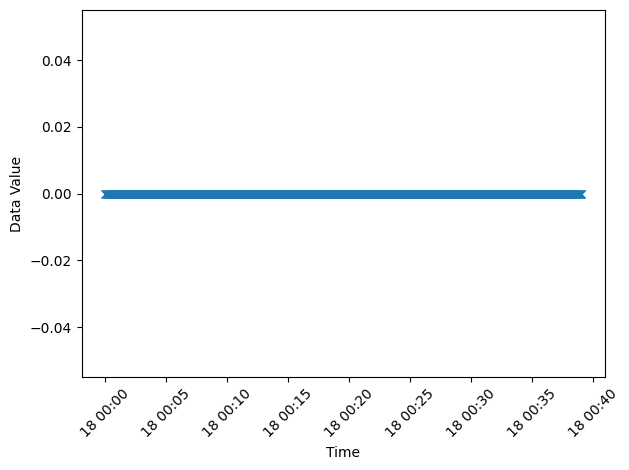

In [12]:
first_day = datetime(1900, 1, 1, 0, 0, 0)   # starting date for the transducer time format
    
time     = first_day + np.array([timedelta(days=d) for d in pump_data.iloc[:, 1]]) - relativedelta(days = 2) 
time     = time - timedelta(hours = 7)


target_date = datetime(year=2024, month=7, day=18)

mask = (time >= target_date) & (time < target_date + timedelta(days=1))

# Apply the mask to filter the time and corresponding data
filtered_time = time[mask]
filtered_data = pump_data.iloc[mask, 3]  # Assuming the data to plot is in the fourth column

# Plot the filtered data
plt.plot(filtered_time, filtered_data, 'x')
plt.xlabel('Time')
plt.ylabel('Data Value')
plt.xticks(rotation=45)
plt.tight_layout()
#plt.ylim(0, 7)
plt.show()

### Loading pressure data 

In [13]:

def load_all_files_pressure(directory):
    data = []
    file_pattern = os.path.join(directory, "prexp*")
    files = glob.glob(file_pattern)
    for file_path in files:
        pressure_file = pd.read_table(file_path, header=None)
        data.append(pressure_file)
    return pd.concat(data, ignore_index=True)

directory = "E:\\Otway_cores\\pressure_data_round2\\"
pressure_data = load_all_files_pressure(directory)



## GFV 9V

Offset to center the circle: (x: 293, y: 278)
Offset to center the circle: (x: 283, y: 280)
wet
Offset to center the circle: (x: 293, y: 277)
Offset to center the circle: (x: 284, y: 280)
dry
The average porosity is 0.3482747742633876


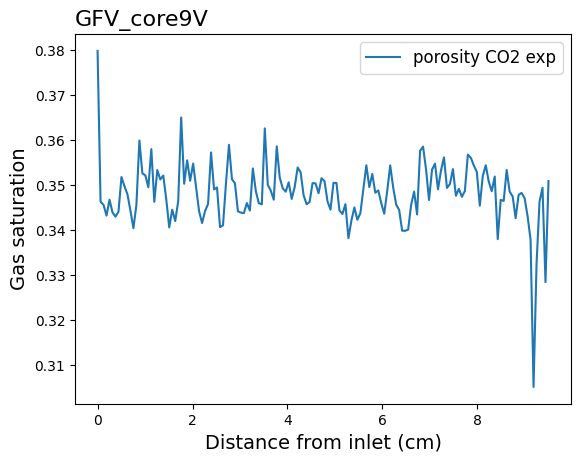

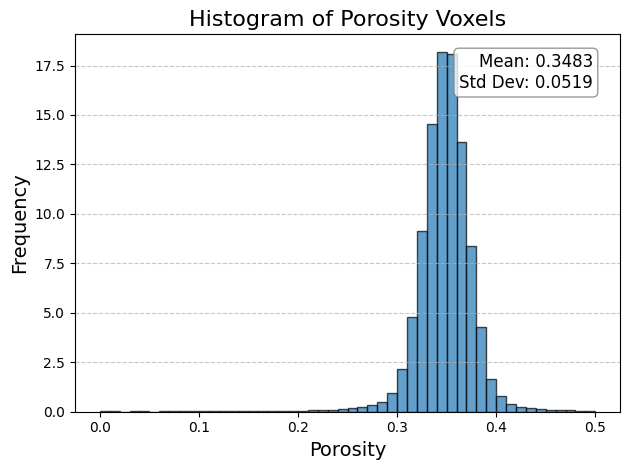

interactive(children=(IntSlider(value=1, description='Downsample Rate:', max=5, min=1), FloatSlider(value=1.0,…

Offset to center the circle: (x: 292, y: 277)
Offset to center the circle: (x: 277, y: 278)
exp
The average saturation for the core is 0.2560401950254019
Offset to center the circle: (x: 292, y: 277)
Offset to center the circle: (x: 277, y: 278)
exp
The average saturation for the core is 0.22531537162235363


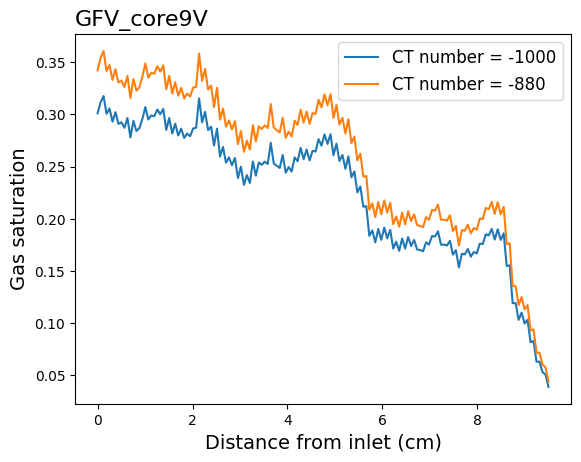

interactive(children=(IntSlider(value=1, description='Downsample Rate:', max=5, min=1), FloatSlider(value=1.0,…

In [14]:
file_path = "E:\\Otway_cores\\"
exp = 'GFV_core9V'


#input parameters 
input_parameters = {
    'CT_water': 0,
    'CT_air': -1000,
    'coarse': 8,
    'rockin': 10,
    'rockout': 162,
    'num_slices': 166,
    'Slicethick': 0.625,
    'Voxsize': 0.1875,
    'cr': 105
}

folder_names, path_to_files = get_folder_names(exp, file_path)
processed_images_wet, ct_numbers_wet, time_wet = load_process_scan(path_to_files, 
                                                                   "wet", 
                                                                   0, 
                                                                   input_parameters['num_slices'],  
                                                                   cr = input_parameters['cr'])

processed_images_dry, ct_numbers_dry, time_dry = load_process_scan(path_to_files, 
                                                                   "dry", 
                                                                   input_parameters['num_slices'], 
                                                                   input_parameters['num_slices'],  
                                                                   cr = input_parameters['cr'])

porosity_voxels, core_averaged_porosity, slice_averaged_porosity = calculate_porosity(processed_images_dry,
                                                                                      processed_images_wet, 
                                                                                      CT_water = input_parameters['CT_water'], 
                                                                                      CT_air = input_parameters['CT_air'], 
                                                                                      coarse = input_parameters['coarse'], 
                                                                                      rockin = input_parameters['rockin'], 
                                                                                      rockout = input_parameters['rockout'])


plot_slice_averaged_profiles(slice_averaged_porosity, 'porosity CO2 exp', exp)

print('The average porosity is', np.mean(slice_averaged_porosity))
plt.show()

histogram(porosity_voxels.flatten())

voxel_map_3D(porosity_voxels, 'Porosity', 0,  1)


processed_images, ct_numbers, time_scan = load_process_scan(path_to_files, "exp", 3652, input_parameters['num_slices'], cr=input_parameters['cr'])
saturation_voxels, core_averaged_sat, slice_averaged_sat_880 = calculate_saturation(processed_images, 
                                                                                    processed_images_wet, 
                                                                                    porosity_voxels, 
                                                                                    slice_averaged_porosity, 
                                                                                    CT_water=input_parameters['CT_water'], 
                                                                                    CT_air = -880, 
                                                                                    coarse=input_parameters['coarse'], 
                                                                                    rockin=input_parameters['rockin'], 
                                                                                    rockout=input_parameters['rockout'])




processed_images, ct_numbers,  time_scan = load_process_scan(path_to_files, "exp", 3652, input_parameters['num_slices'],  cr=input_parameters['cr'])
saturation_voxels, core_averaged_sat, slice_averaged_sat_1000 = calculate_saturation(processed_images, 
                                                                                    processed_images_wet, 
                                                                                    porosity_voxels, 
                                                                                    slice_averaged_porosity, 
                                                                                    CT_water=input_parameters['CT_water'], 
                                                                                    CT_air = -1000, 
                                                                                    coarse=input_parameters['coarse'], 
                                                                                    rockin=input_parameters['rockin'], 
                                                                                    rockout=input_parameters['rockout'])


plot_slice_averaged_profiles(slice_averaged_sat_1000, 'CT number = -1000', exp)
plot_slice_averaged_profiles(slice_averaged_sat_880, 'CT number = -880', exp)

voxel_map_3D(saturation_voxels, 'Gas saturation', 0,  1)




In [15]:
#np.savetxt('porosity_voxels_core9V.txt', porosity_voxels.flatten())



### Flow images 

Offset to center the circle: (x: 292, y: 277)
Offset to center the circle: (x: 281, y: 278)
exp
Offset to center the circle: (x: 289, y: 277)
Offset to center the circle: (x: 280, y: 278)
exp
Mean CT number 2594.710433738788
Offset to center the circle: (x: 292, y: 277)
Offset to center the circle: (x: 281, y: 278)
exp
Mean CT number 2594.85239407568
The average saturation for the core is 0.03565945744519818
[8.693677135261682]
2024-03-01 11:17:40


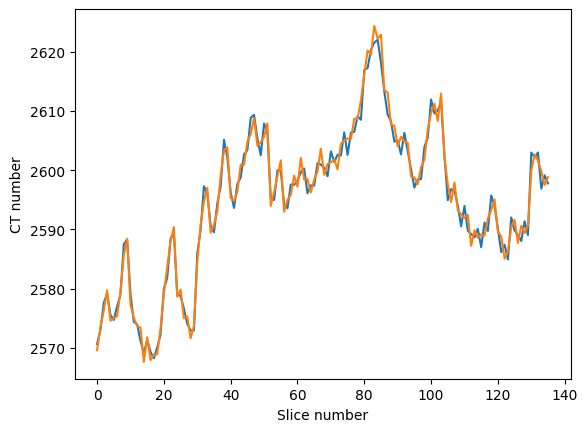

interactive(children=(IntSlider(value=1, description='Downsample Rate:', max=5, min=1), FloatSlider(value=1.0,…

Offset to center the circle: (x: 292, y: 277)
Offset to center the circle: (x: 280, y: 280)
exp
Offset to center the circle: (x: 293, y: 278)
Offset to center the circle: (x: 280, y: 278)
exp
Mean CT number 2590.2108011628443
Offset to center the circle: (x: 292, y: 277)
Offset to center the circle: (x: 280, y: 280)
exp
Mean CT number 2590.302023211006
The average saturation for the core is 0.04643685888666367
[13.558492503384505]
2024-03-01 11:32:38


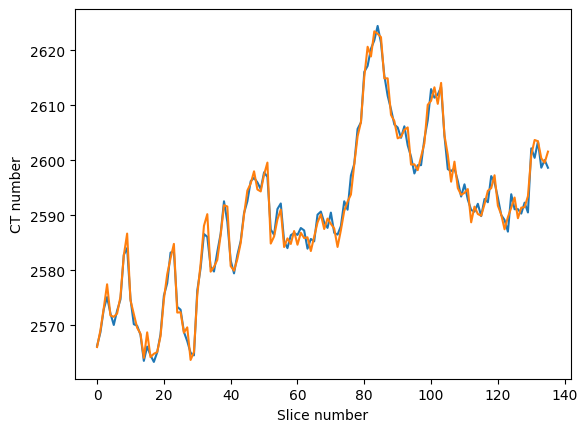

interactive(children=(IntSlider(value=1, description='Downsample Rate:', max=5, min=1), FloatSlider(value=1.0,…

Offset to center the circle: (x: 292, y: 278)
Offset to center the circle: (x: 281, y: 278)
exp
Offset to center the circle: (x: 292, y: 278)
Offset to center the circle: (x: 281, y: 278)
exp
Mean CT number 2578.7822598320977
Offset to center the circle: (x: 292, y: 278)
Offset to center the circle: (x: 281, y: 278)
exp
Mean CT number 2577.0901575803196
The average saturation for the core is 0.07851992240045881
[12.511613359631056]
2024-03-01 11:51:59


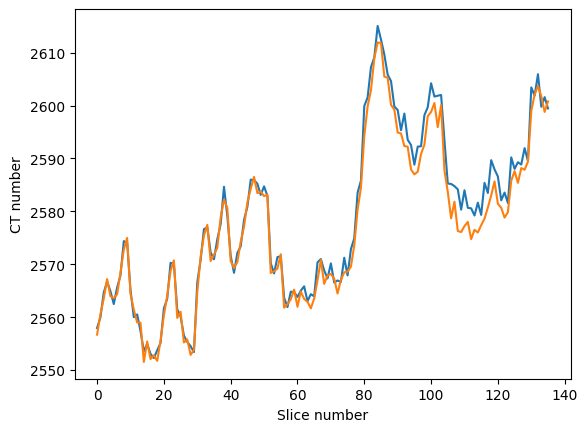

interactive(children=(IntSlider(value=1, description='Downsample Rate:', max=5, min=1), FloatSlider(value=1.0,…

Offset to center the circle: (x: 289, y: 277)
Offset to center the circle: (x: 281, y: 278)
exp
Offset to center the circle: (x: 289, y: 278)
Offset to center the circle: (x: 280, y: 277)
exp


In [ ]:
# Dictionary to store variables
slice_averaged_sat_dict = {}
pressure_dict           = {}
voxel_sat_dict          = {}

num_slices = input_parameters["num_slices"]

for i in range(0, 4648, num_slices*2):
    sat, sat_voxels, pressure = processing_workflow(i, processed_images_wet, -880, 'exp')
    slice_averaged_sat_dict[f'slice_averaged_sat_{i}'] = sat
    pressure_dict[f'pressure_{i}']                     = pressure
    voxel_sat_dict[f'voxel_sat_{i}']                   = sat_voxels

    


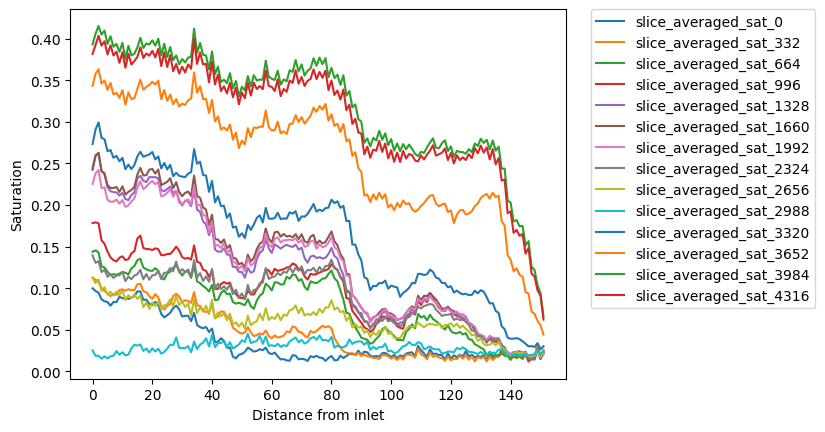

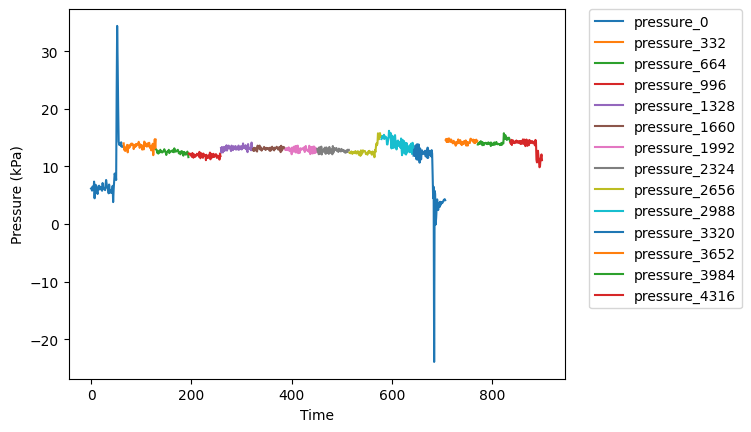

CSV file saved to: E:/Otway_cores/trapping_data\trapping_data.csv


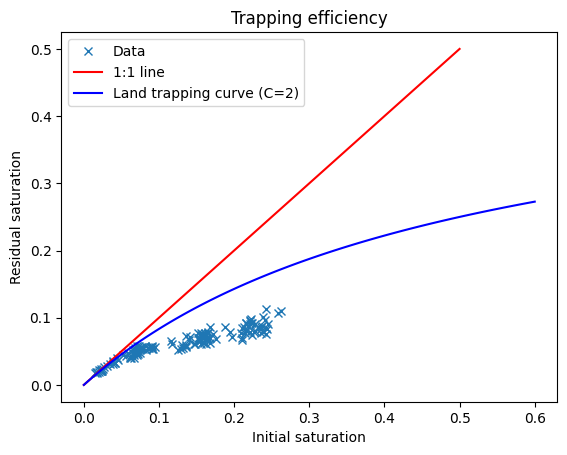

In [17]:

plotting_saturation(slice_averaged_sat_dict)
plotting_pressure(pressure_dict)
trapping_efficiency(slice_averaged_sat_dict, 1660, 2656)

Ratio of values in the first 10 bins to the next 40 bins: 5.076047207446808
Ratio of values in the first 10 bins to the next 40 bins: 13.367795950155763


Text(0.5, 1.0, 'Saturation voxel distributions')

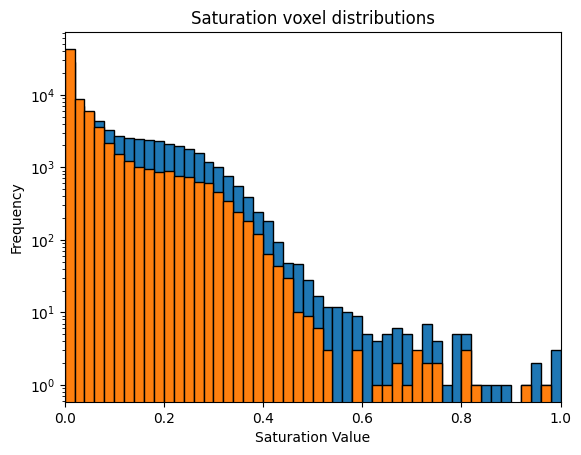

In [18]:
voxel_sat_distribution(voxel_sat_dict, 2324)
voxel_sat_distribution(voxel_sat_dict, 332)
plt.yscale('log')
plt.title('Saturation voxel distributions')

#### Relative permeability 

0.5296484162598155
0.16980473031998614
0.07360509302536986
0.038781825254674565
0.0
0.035208247563120736
0.07133559607378635
0.1805840695518726
0.35988633881297977
0.6548959867548131
0.0
0.0
0.0
0.0


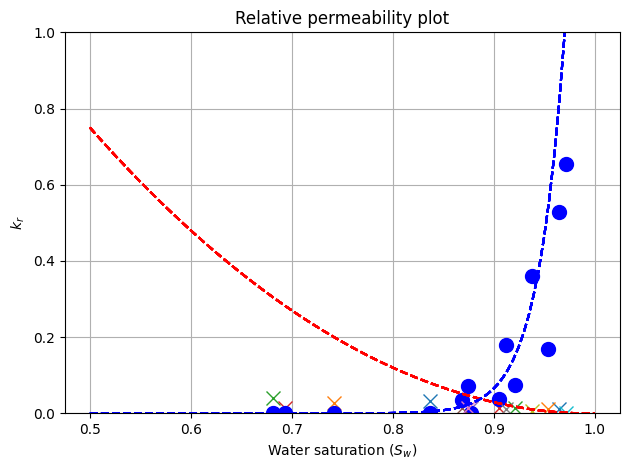

In [19]:
## extraction of flow rate and fw can be done with pumps when you use Disco 



#################


flow_rate = [4,4,4,4,4,4,4,4,4,4,6,8,12,4]
fw        = [0.5, 0.25, 0.1, 0.05, 0, 0.05, 0.1, 0.25, 0.5, 1, 0, 0, 0, 0]


#################
plt.figure()
cnt = 0
for i in range(0, 4648, num_slices*2):
    mean_pressure = find_mean_pressure_dict(pressure_dict, i)
    mean_sat = find_mean_sat_dict(slice_averaged_sat_dict, i)
    sat, kr, kr_w = rel_perm_calc(exp='GFV_9V_CO2', sat=mean_sat, pressure=mean_pressure*10**3, flow_rate=flow_rate[cnt], fw=fw[cnt], mu='CO2', lam = 0.06, kr_nw_end_point=3, kr_w_end_point=1.8)
    cnt +=1 
    print(kr_w)

#composite_rel_perm(Sw_comp, Kg_comp, Kw_comp)

plt.grid()
plt.xlabel('Water saturation ($S_w$)')
plt.ylabel('$k_r$')
#plt.yscale('log')
plt.ylim(0,1)
plt.title('Relative permeability plot')
plt.tight_layout()

